# Lab4_1

**Bài tập 1: Thuật toán Gradient Descent**

- Thêm thư viện

In [41]:
import numpy as np
import matplotlib.pyplot as plt

- Hàm gradient_descent nhận vào hàm số, đạo hàm của hàm số, giá trị khởi tạo, learning rate và step:

In [42]:
def gradient_descent(f, df, x_init, lr=0.1, steps=10):
    x_vals = [x_init]
    x = x_init
    print(f'{"Step":<5} {"x":>10} {"f(x)":>15}')
    print("-" * 30)
    for i in range(steps):
        fx = f(x)
        print(f"{i:<5} {x:>10.5f} {fx:>15.5f}")
        x = x - lr * df(x)
        x_vals.append(x)
    fx = f(x)
    print(f"{steps:<5} {x:>10.5f} {fx:>15.5f}")
    return x_vals

- Hàm vẽ biểu đồ minh hoạ kết quả

In [52]:
def plot_descent(f, df, x_init, lr, steps, title, xlim=(-10, 10), ylim=None):
    x_vals = gradient_descent(f, df, x_init, lr, steps)
    x_range = np.linspace(xlim[0], xlim[1], 1000)
    y_range = f(x_range)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_range, y_range, label='Function', color='blue')
    ax.scatter(x_vals, [f(x) for x in x_vals], color='red', label='Descent Steps', clip_on=True)

    for i in range(len(x_vals) - 1):
        ax.arrow(
            x_vals[i], f(x_vals[i]),
            x_vals[i+1] - x_vals[i], f(x_vals[i+1]) - f(x_vals[i]),
            head_width=0.3, color='green', length_includes_head=True, clip_on=True
        )

    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.legend()
    # Giữ đúng khung nhìn như GV (tránh autoscale theo điểm x rất âm khi GD phân kỳ)
    ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.set_autoscale_on(False)
    plt.show()

- Thử nghiệm với hàm bậc 2, bậc 3, bậc 4:

In [53]:
f1 = lambda x: x**2
df1 = lambda x: 2*x

f2 = lambda x: x**3
df2 = lambda x: 3*x**2

f3 = lambda x: x**4 - 3*x**3 + 2
df3 = lambda x: 4*x**3 - 9*x**2

- Gọi hàm vẽ biểu đồ để quan sát kết quả:

Step           x            f(x)
------------------------------
0        8.00000        64.00000
1        3.20000        10.24000
2        1.28000         1.63840
3        0.51200         0.26214
4        0.20480         0.04194
5        0.08192         0.00671
6        0.03277         0.00107
7        0.01311         0.00017
8        0.00524         0.00003
9        0.00210         0.00000
10       0.00084         0.00000


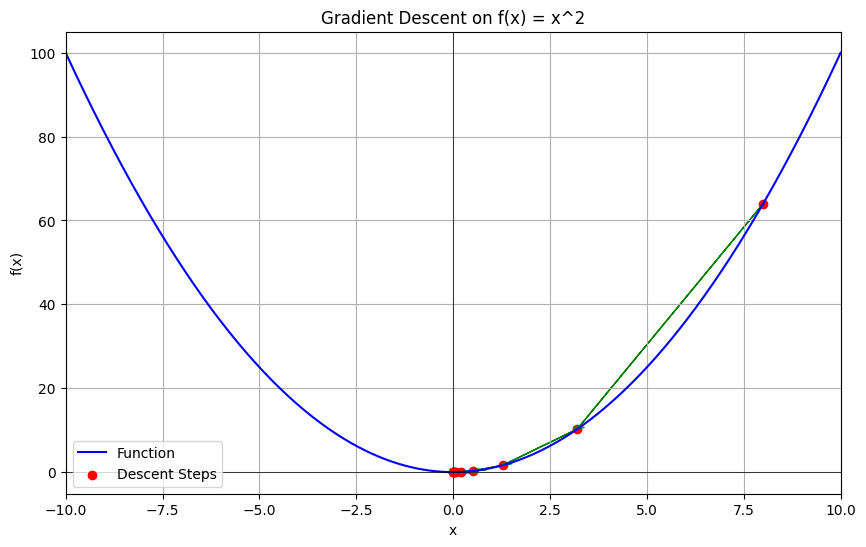

In [54]:
# Hàm bậc 2
plot_descent(f1, df1, x_init=8, lr=0.3, steps=10, title='Gradient Descent on f(x) = x^2', xlim=(-10, 10))

Step           x            f(x)
------------------------------
0       -2.00000        -8.00000
1       -2.12000        -9.52813
2       -2.25483       -11.46417
3       -2.40736       -13.95157
4       -2.58122       -17.19792
5       -2.78110       -21.51053
6       -3.01314       -27.35630
7       -3.28551       -35.46564
8       -3.60935       -47.02031
9       -4.00017       -64.00802
10      -4.48021       -89.92786
11      -5.08237      -131.28045
12      -5.85729      -200.95108
13      -6.88653      -326.58832
14      -8.30925      -573.70161
15     -10.38056     -1118.56943
16     -13.61325     -2522.81448
17     -19.17286     -7047.92072
18     -30.20083    -27545.86956
19     -57.56352   -190740.15237
20    -156.97030  -3867697.47854


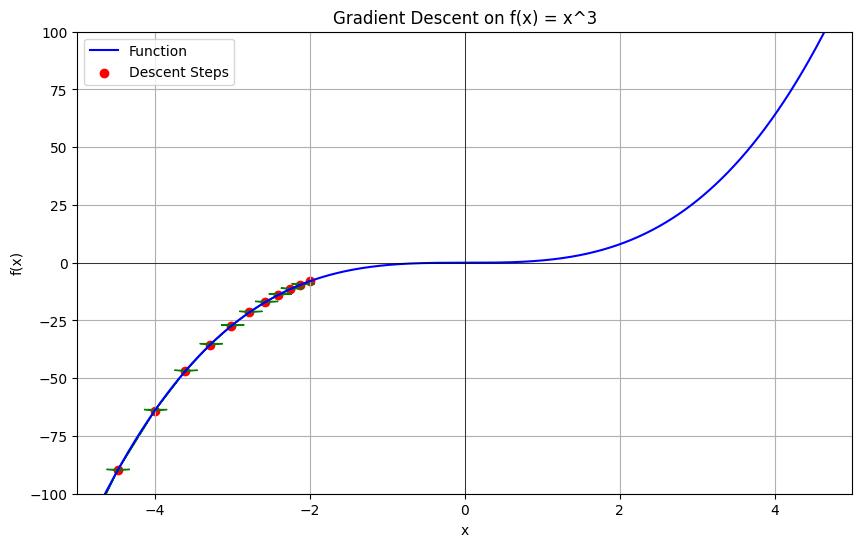

In [55]:
# Hàm bậc 3
plot_descent(f2, df2, x_init=-2, lr=0.01, steps=20, 
            title='Gradient Descent on f(x) = x^3', 
            xlim=(-5, 5), ylim=(-100, 100))

Step           x            f(x)
------------------------------
0        6.00000       650.00000
1        0.60000         1.48160
2        0.62376         1.42331
3        0.64907         1.35715
4        0.67605         1.28194
5        0.70482         1.19637
6        0.73553         1.09892
7        0.76830         0.98789
8        0.80328         0.86137
9        0.84062         0.71727
10       0.88046         0.55332
11       0.92293         0.36711
12       0.96815         0.15620
13       1.01621        -0.08181
14       1.06717        -0.34906
15       1.12105        -0.64723
16       1.17780        -0.97725
17       1.23730        -1.33890
18       1.29931        -1.73049
19       1.36351        -2.14849
20       1.42944        -2.58723
21       1.49650        -3.03890
22       1.56400        -3.49371
23       1.63112        -3.94052
24       1.69699        -4.36772
25       1.76069        -4.76438
26       1.82136        -5.12147
27       1.87824        -5.43282
28       1.9

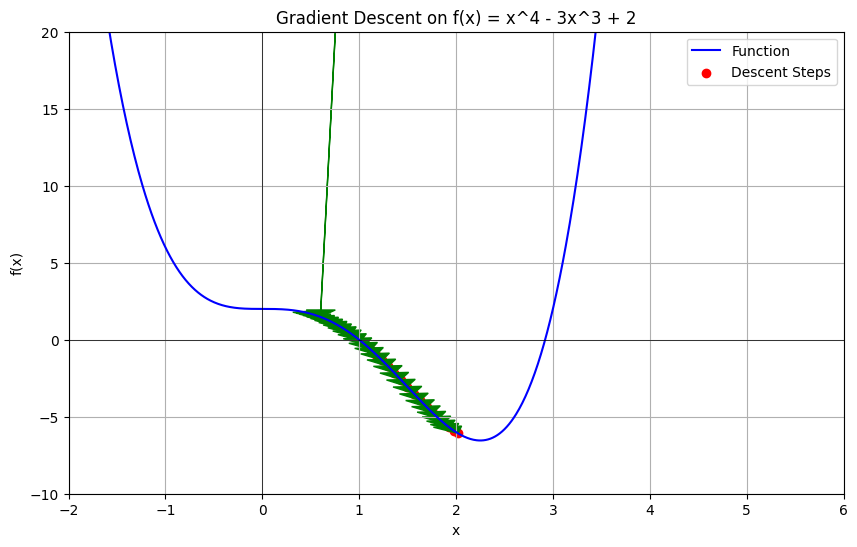

In [63]:
# Hàm bậc 4
plot_descent(f3, df3, x_init=6, lr=0.01, steps=30,
        title='Gradient Descent on f(x) = x^4 - 3x^3 + 2',
        xlim=(-2, 6), ylim=(-10, 20)
    )

**Thử nghiệm với bài toán hồi quy**

- Thêm thư viện

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Step         w         Loss       grad
-----------------------------------
0       0.0000     349.7034  -216.0585
1       0.2161     304.6191  -201.2756
2       0.4173     265.4932  -187.5041
3       0.6048     231.5382  -174.6749
4       0.7795     202.0707  -162.7234
5       0.9422     176.4976  -151.5897
6       1.0938     154.3043  -141.2178
7       1.2350     135.0441  -131.5555
8       1.3666     118.3293  -122.5544
9       1.4892     103.8236  -114.1691
10      1.6033      91.2349  -106.3575
11      1.7097      80.3100   -99.0804
12      1.8088      70.8289   -92.3012
13      1.9011      62.6009   -85.9859
14      1.9870      55.4602   -80.1026
15      2.0672      49.2633   -74.6219
16      2.1418      43.8854   -69.5162
17      2.2113      39.2182   -64.7598
18      2.2760      35.1678   -60.3289
19      2.3364      31.6528   -56.2011
20      2.3926      28.6023   -52.3558
21      2.4449      25.9549   -48.7736
22      2.4937      23.6574   -45.4364
23      2.5391      21.6636 

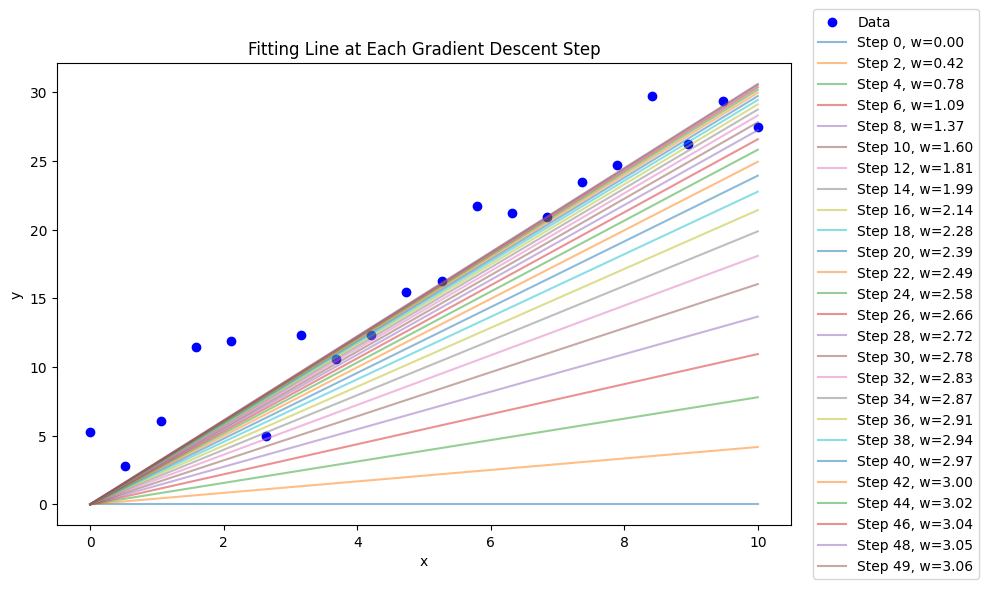

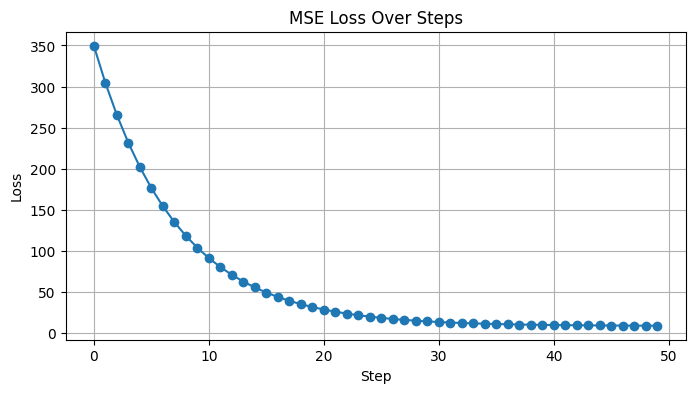

In [98]:
np.random.seed(0)
x_data = np.linspace(0, 10, 20)
y_data = 3.0 * x_data + np.random.randn(*x_data.shape) * 3  # true w = 3.0

w = 0.0
lr = 0.001
steps = 50

w_history = []
loss_history = []

# Tạo DataFrame chứa cột x_data và y_data để hiển thị bên cạnh đồ thị (bảng dữ liệu)
data_df = pd.DataFrame({
    "x_data": x_data,
    "y_data": y_data
})

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label='Data', color='blue')

print(f"{'Step':<5} {'w':>8} {'Loss':>12} {'grad':>10}")
print("-" * 35)

for step in range(steps):
    y_pred = w * x_data
    loss = np.mean((y_pred - y_data) ** 2)
    grad = np.mean(2 * x_data * (y_pred - y_data))
    
    print(f"{step:<5} {w:>8.4f} {loss:>12.4f} {grad:>10.4f}")
    
    w_history.append(w)
    loss_history.append(loss)
    
    # Plot fit line for this step
    if step % 2 == 0 or step == steps - 1:  # Show every few steps
        plt.plot(x_data, w * x_data, label=f'Step {step}, w={w:.2f}', alpha=0.5)
    
    # Update weight
    w -= lr * grad

plt.title('Fitting Line at Each Gradient Descent Step')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

# Thêm bảng MSE Loss (MSE theo từng bước)
mse_df = pd.DataFrame({
    "Step": np.arange(steps),
    "MSE Loss": loss_history
})
# Vẽ biểu đồ đường của MSE Loss như ví dụ hình bạn cung cấp
plt.figure(figsize=(8, 4))
plt.plot(np.arange(steps), loss_history, marker='o')
plt.title('MSE Loss Over Steps')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Bài tập 2

- Install libraries

In [99]:
%pip install torch torchvision matplotlib

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/114.6 MB 3.6 MB/s eta 0:00:32
    --------------------------------------- 2.1/114.6 MB 3.8 MB/s eta 0:00:30
   - -------------------------------------- 3.4/114.6 MB 4.5 MB/s eta 0:00:25
   - -------------------------------------- 4.5/114.6 MB 4.7 MB/s eta 0:00:24
   -- ------------------------------------- 5.8/114.6 MB 4.9 MB/s eta 0:00:23
   -- ------------------------------------- 6.8/114.6 MB 5.0 MB/s eta 0:00:22
   -- ------------------------------------- 7.9/114.6 MB 5.0 MB/s eta 0:00:22
   --- ------------------------------------ 9.2/114.6 MB 5.0 MB/s eta 0:00:21
   --- -------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Import libraries

In [106]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

- Khởi tạo các siêu tham số, kiểm tra GPU

In [107]:
BATCH_SIZE = 64
EPOCHS = 5
LR = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


- Khởi tạo dataset, tạo tập train và tập test:

In [108]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

In [109]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

- Gọi một đối tượng ảnh trong tập dataset:

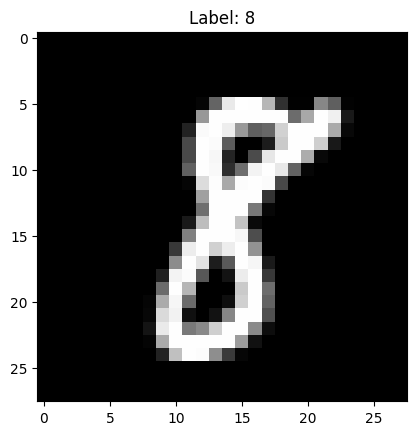

In [134]:
images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

- Kiến trúc mạng MLP sử dụng:

In [135]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

- Kiến trúc mạng CNN sử dụng:

In [136]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

- Hàm huấn luyện, hàm này đưa dữ liệu vào mô hình sau đó tính toán và cập nhật trọng số:

In [137]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

- Hàm đánh giá:

In [138]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

- Tiến hành huấn luyện mô hình:

In [139]:
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Training MLP...")

for epoch in range(EPOCHS):
    loss = train(model, train_loader, optimizer, criterion)
    acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}")

Training MLP...
Epoch 1: Loss=0.3490, Acc=0.9502
Epoch 2: Loss=0.1424, Acc=0.9668
Epoch 3: Loss=0.0986, Acc=0.9713
Epoch 4: Loss=0.0724, Acc=0.9734
Epoch 5: Loss=0.0569, Acc=0.9720


- Tương tự với mô hình CNN:

In [140]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Training CNN...")

for epoch in range(EPOCHS):
    loss = train(model, train_loader, optimizer, criterion)
    acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}")

Training CNN...
Epoch 1: Loss=0.1864, Acc=0.9835
Epoch 2: Loss=0.0479, Acc=0.9886
Epoch 3: Loss=0.0341, Acc=0.9881
Epoch 4: Loss=0.0261, Acc=0.9908
Epoch 5: Loss=0.0196, Acc=0.9898


# Bài tập 3

- Install and import dataset

In [153]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [154]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from tqdm import tqdm 

- Khởi tạo giá trị siêu tham số, kiểm tra GPU:

In [143]:
BATCH_SIZE = 128
EPOCHS = 10
LR = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


- Khởi tạo bộ dữ liệu train và test:

In [144]:
from torchvision.datasets import ImageFolder

TRAIN_DIR = "cifar10/train"
TEST_DIR = "cifar10/test"

transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5))
])

train_dataset = ImageFolder(root=TRAIN_DIR, transform=transform_train)
test_dataset = ImageFolder(root=TEST_DIR, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

classes = train_dataset.classes
print("Classes:", classes)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


- Kiểm tra một phần tử trong bộ dữ liệu huấn luyện:

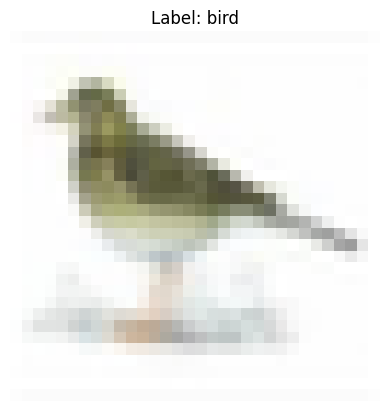

In [146]:
images, labels = next(iter(train_loader))

img = images[0] / 2 + 0.5  # unnormalize
img = img.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Label: {classes[labels[0].item()]}")
plt.axis("off")
plt.show()

- Hàm huấn luyện mô hình:

In [147]:
from tqdm.notebook import tqdm, trange

def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Train", leave=False)

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct / total:.4f}"
        })

    avg_loss = total_loss / len(loader)
    avg_acc = correct / total
    return avg_loss, avg_acc

- Hàm đánh giá mô hình:

In [148]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Eval", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{correct / total:.4f}"
            })

    avg_loss = total_loss / len(loader)
    avg_acc = correct / total
    return avg_loss, avg_acc

- Hàm triển khai quá trình huấn luyện:

In [149]:
def run_training(model, train_loader, test_loader, criterion, optimizer, device, epochs, model_name="Model"):
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    print(f"Training {model_name}...")

    for epoch in range(epochs):
        print(f"{model_name} Epoch {epoch + 1}/{epochs}")

        train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
        )

    return train_losses, train_accs, test_losses, test_accs

- Khởi tạo kiến trúc CNN huấn luyện:

In [150]:
import torch.nn as nn

class BasicCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                            # 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),# 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                            # 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8
            nn.ReLU(),
            nn.MaxPool2d(2)                             # 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

- Huấn luyện mô hình CNN vừa khởi tạo:

In [159]:
model = BasicCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

cnn_train_losses, cnn_train_accs, cnn_test_losses, cnn_test_accs = run_training(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_name="BasicCNN"
)

Training BasicCNN...
BasicCNN Epoch 1/10


Epoch 1/10 | Train Loss: 1.5800 | Train Acc: 0.4242 | Test Loss: 1.2489 | Test Acc: 0.5472
BasicCNN Epoch 2/10


Epoch 2/10 | Train Loss: 1.1977 | Train Acc: 0.5706 | Test Loss: 1.0104 | Test Acc: 0.6348
BasicCNN Epoch 3/10


Epoch 3/10 | Train Loss: 1.0217 | Train Acc: 0.6404 | Test Loss: 0.9044 | Test Acc: 0.6848
BasicCNN Epoch 4/10


Epoch 4/10 | Train Loss: 0.9109 | Train Acc: 0.6818 | Test Loss: 0.8249 | Test Acc: 0.7106
BasicCNN Epoch 5/10


...

Epoch 6/10 | Train Loss: 0.7773 | Train Acc: 0.7293 | Test Loss: 0.7291 | Test Acc: 0.7484
BasicCNN Epoch 7/10


Epoch 7/10 | Train Loss: 0.7274 | Train Acc: 0.7471 | Test Loss: 0.7565 | Test Acc: 0.7367
BasicCNN Epoch 8/10


Epoch 8/10 | Train Loss: 0.6904 | Train Acc: 0.7590 | Test Loss: 0.6822 | Test Acc: 0.7629
BasicCNN Epoch 9/10


Epoch 9/10 | Train Loss: 0.6550 | Train Acc: 0.7722 | Test Loss: 0.6896 | Test Acc: 0.7575
BasicCNN Epoch 10/10


Epoch 10/10 | Train Loss: 0.6254 | Train Acc: 0.7816 | Test Loss: 0.6598 | Test Acc: 0.7690


- Khởi tạo mô hình VGG16 và huấn luyện:

In [162]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

vgg_train_losses, vgg_train_accs, vgg_test_losses, vgg_test_accs = run_training(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_name="VGG16"
)

Training VGG16...
VGG16 Epoch 1/10


Epoch 1/10 | Train Loss: 1.6571 | Train Acc: 0.3268 | Test Loss: 1.2796 | Test Acc: 0.4639
VGG16 Epoch 2/10


Epoch 2/10 | Train Loss: 1.0044 | Train Acc: 0.6422 | Test Loss: 1.0407 | Test Acc: 0.6484
VGG16 Epoch 3/10


Epoch 3/10 | Train Loss: 0.7477 | Train Acc: 0.7605 | Test Loss: 0.7447 | Test Acc: 0.7594
VGG16 Epoch 4/10


Epoch 4/10 | Train Loss: 0.6415 | Train Acc: 0.8000 | Test Loss: 0.6713 | Test Acc: 0.7916
VGG16 Epoch 5/10


...

Epoch 6/10 | Train Loss: 0.5210 | Train Acc: 0.8397 | Test Loss: 0.6033 | Test Acc: 0.8210
VGG16 Epoch 7/10


Epoch 7/10 | Train Loss: 0.4727 | Train Acc: 0.8552 | Test Loss: 0.6028 | Test Acc: 0.8204
VGG16 Epoch 8/10


Epoch 8/10 | Train Loss: 0.4803 | Train Acc: 0.8570 | Test Loss: 0.6031 | Test Acc: 0.8200
VGG16 Epoch 9/10


Epoch 9/10 | Train Loss: 0.4619 | Train Acc: 0.8624 | Test Loss: 0.5643 | Test Acc: 0.8248
VGG16 Epoch 10/10


Epoch 10/10 | Train Loss: 0.4470 | Train Acc: 0.8664 | Test Loss: 0.5562 | Test Acc: 0.8394


- Khởi tạo mô hình ResNet18 và huấn luyện:

In [164]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

resnet_train_losses, resnet_train_accs, resnet_test_losses, resnet_test_accs = run_training(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_name="ResNet18"
)

Training ResNet18...
ResNet18 Epoch 1/10


Epoch 1/10 | Train Loss: 0.8879 | Train Acc: 0.7007 | Test Loss: 0.7237 | Test Acc: 0.7559
ResNet18 Epoch 2/10


Epoch 2/10 | Train Loss: 0.6094 | Train Acc: 0.7931 | Test Loss: 0.6385 | Test Acc: 0.7840
ResNet18 Epoch 3/10


Epoch 3/10 | Train Loss: 0.5100 | Train Acc: 0.8254 | Test Loss: 0.5771 | Test Acc: 0.8059
ResNet18 Epoch 4/10


Epoch 4/10 | Train Loss: 0.4491 | Train Acc: 0.8479 | Test Loss: 0.5662 | Test Acc: 0.8102
ResNet18 Epoch 5/10


...

Epoch 6/10 | Train Loss: 0.3413 | Train Acc: 0.8841 | Test Loss: 0.5561 | Test Acc: 0.8188
ResNet18 Epoch 7/10


Epoch 7/10 | Train Loss: 0.3123 | Train Acc: 0.8945 | Test Loss: 0.6502 | Test Acc: 0.8004
ResNet18 Epoch 8/10


Epoch 8/10 | Train Loss: 0.2957 | Train Acc: 0.9007 | Test Loss: 0.5656 | Test Acc: 0.8194
ResNet18 Epoch 9/10


Epoch 9/10 | Train Loss: 0.2501 | Train Acc: 0.9136 | Test Loss: 0.5286 | Test Acc: 0.8340
ResNet18 Epoch 10/10


Epoch 10/10 | Train Loss: 0.2122 | Train Acc: 0.9291 | Test Loss: 0.5825 | Test Acc: 0.8269


- Hàm kiểm tra độ chính xác của các mô hình sau mỗi epoch:

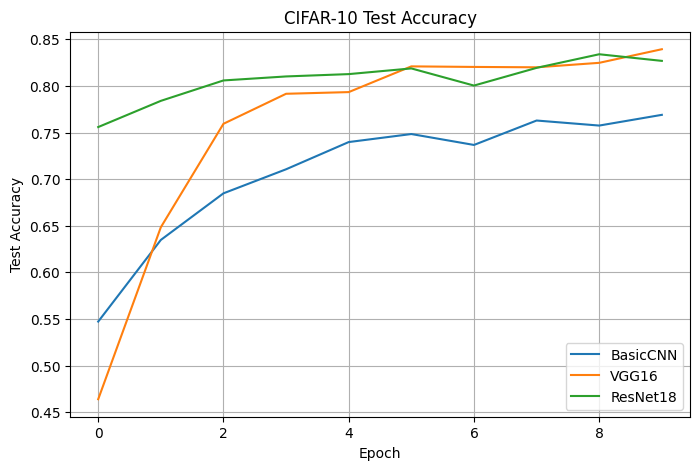

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(cnn_test_accs, label="BasicCNN")
plt.plot(vgg_test_accs, label="VGG16")
plt.plot(resnet_test_accs, label="ResNet18")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("CIFAR-10 Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()